In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Загружаем тренировочный датасет
train_df = pd.read_csv('data/train.csv')


In [4]:
#Смотрим, какие данные и признаки есть в датасете
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#Проверяем количество отсутствующих значений в каждом признаке
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
#Смотрим распределение данных по каждому признаку
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#Выводим общую информация по колонкам, количеству строк и типу данных
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: >

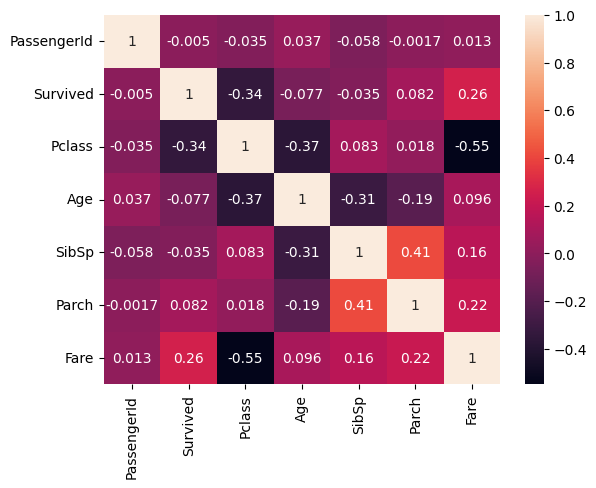

In [8]:
#Посмотрели корреляцию числовых фичей, видно, что самая высокая корреляция у Pclass, SibSp, Age, Fare
sns.heatmap(train_df.corr(numeric_only=True), annot=True)


<Axes: xlabel='Pclass', ylabel='Survived'>

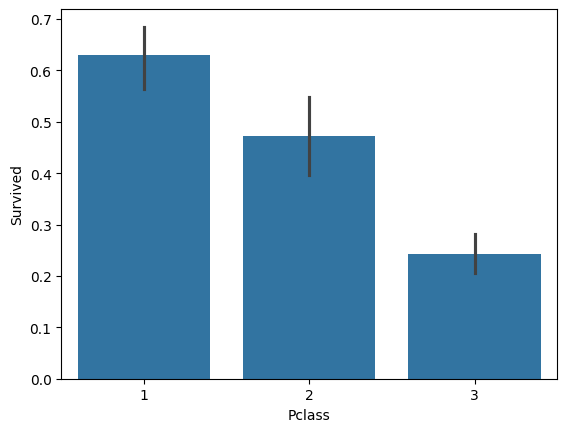

In [ ]:
#Построили столбчатую диаграмму зависимости выживаемости от класса каюты
sns.barplot(x='Pclass', y='Survived', data=train_df)
#Вывод: люди из первого класса выживали чаще

<Axes: xlabel='Survived', ylabel='Fare'>

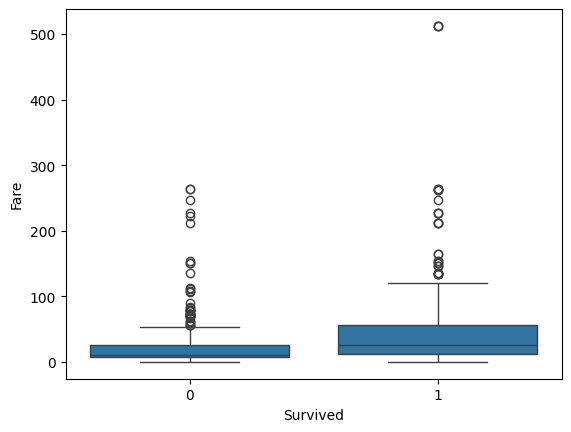

In [ ]:
#Смотрим распределение стоимости билета
sns.boxplot(x="Survived", y="Fare", data=train_df)
#В среднем выживали чаще те люди, которые имели более дорогие билеты

<Axes: xlabel='Sex', ylabel='Survived'>

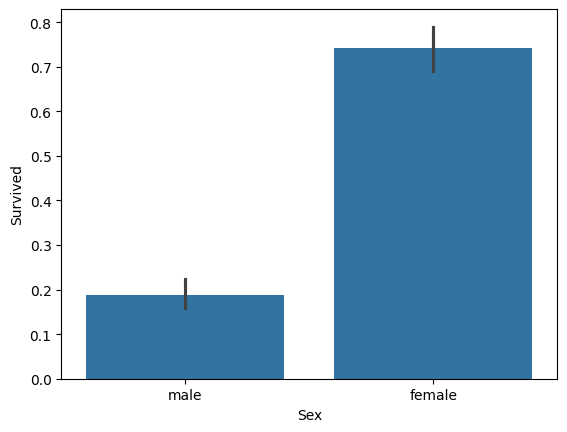

In [ ]:
#Построили столбчатую диаграмму количества мужчин и женщин, которые выжили
sns.barplot(x='Sex', y='Survived', data=train_df)
#Вывод: женщины выживали чаще мужчин


<Axes: xlabel='Survived', ylabel='Age'>

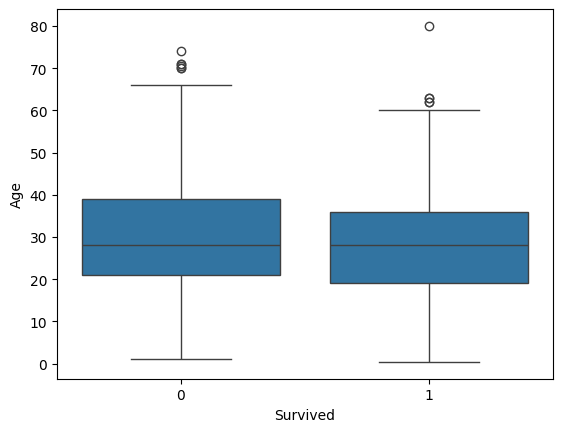

In [ ]:
#Посмотрим возрастное распределение
sns.boxplot(x='Survived', y='Age', data=train_df)
#Вывод: основной возраст пассажиров от 20 до 40 лет

<Axes: xlabel='Age', ylabel='Density'>

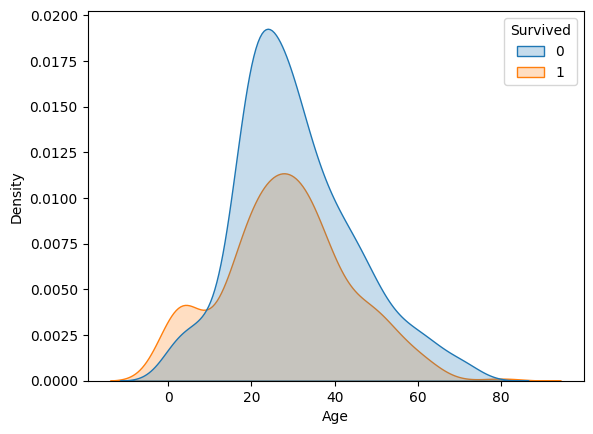

In [ ]:
#Посмотрим на график, который ответит на вопрос - люди какого возраста выживали больше?
sns.kdeplot(data=train_df, x="Age", hue="Survived", fill=True)
#Вывод: люди возраста 25-30 выживали и погибали чаще

In [ ]:
#Создаем новый признак, связанный с кабиной, сейчас у каждой кабины свое уникальное название, но нам нужно просто получить группы, чтобы посмотреть влияние на выживаемость. 
train_df['StrCabin'] = train_df['Cabin'].str[0]
train_df['StrCabin'] = train_df['StrCabin'].fillna('Unknown')
train_df = train_df.drop('Cabin', axis=1)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
 11  StrCabin     204 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: xlabel='StrCabin', ylabel='Survived'>

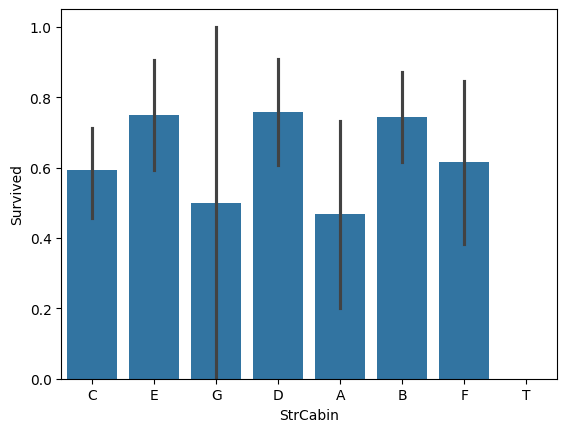

In [ ]:
#Посмотрим график влияние каждой группы кабин на выживаемость
sns.barplot(x='StrCabin', y='Survived', data=train_df)
#Вывод: кабины типа E, D, B имели больший шанс на выживание, возможно они были расположены рядом со спасательными шлюпками

In [ ]:
#У нас есть два похожих признака "SibSp" и "Parch", можно сделать доп признак, который показывает размер семьи
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1

<Axes: xlabel='FamilySize', ylabel='Survived'>

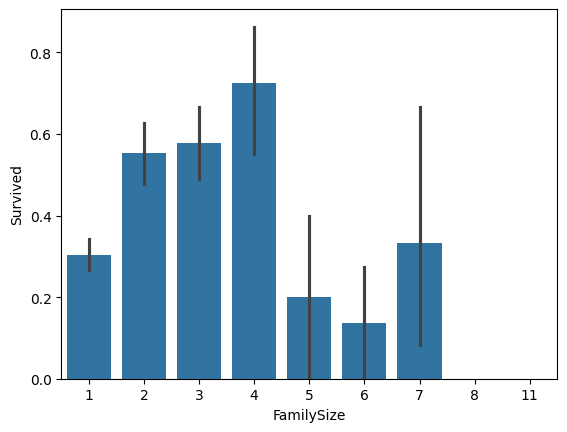

In [ ]:
#Посмотрим график, на котором показано влияние размера семьи на выживаемость
sns.barplot(x='FamilySize', y='Survived', data=train_df)
#Вывод: семьи из 4 человек выживали чаще, так как помогали друг другу спастись, и при этом не было давки и суматохи

In [ ]:
#Теперь можем сделать признак, который будет определять две группы пассажиров - пассажир один или с семьей, насколько это влияет на выживаемость
train_df["IsAlone"] = (train_df["FamilySize"] == 1).astype(int)


<Axes: xlabel='IsAlone', ylabel='Survived'>

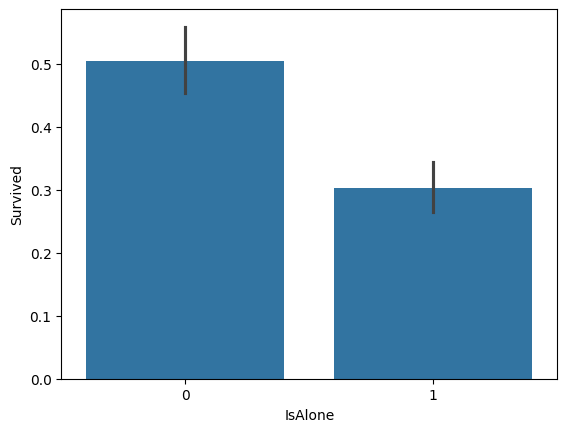

In [ ]:
#Посмотрим график 
sns.barplot(x='IsAlone', y='Survived', data=train_df)
#Вывод: одинокие люди выживали реже

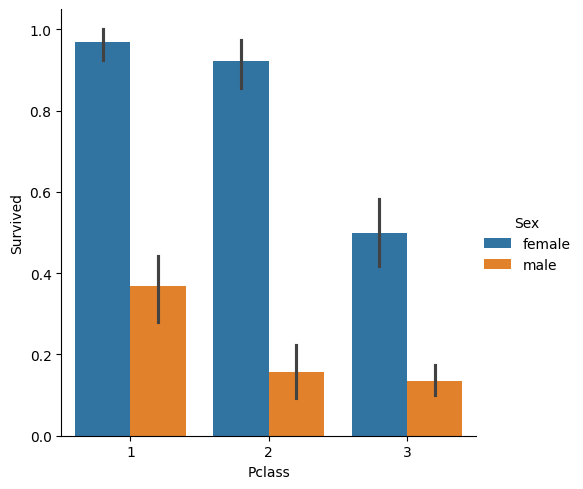

In [15]:
#Посмотрим комбинацию влияния на выживаемость сразу двух признаков - Pclass и Sex
sns.catplot(x="Pclass", y="Survived", hue="Sex", kind="bar", data=train_df)

In [ ]:
#Есть два важных признака - Sex и Pclass, которые мы можем объединить. Данный признак может показать нам высокий процент выживаемости (например, женский пол и высокий класс кают = гарантированная выживаемость)
train_df["Sex_Pclass"] = (train_df["Sex"].astype(str) + "_" + train_df["Pclass"].astype(str))


<Axes: xlabel='Sex_Pclass', ylabel='Survived'>

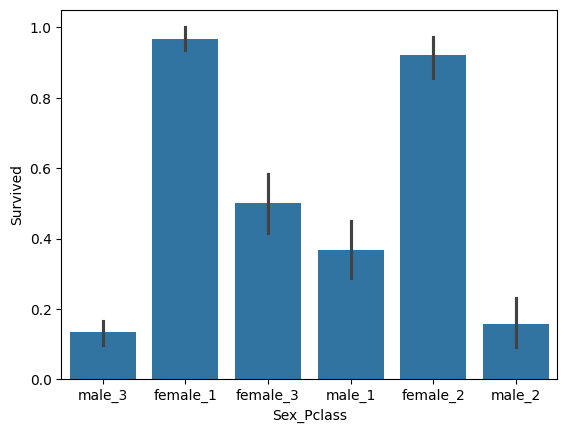

In [ ]:
#Посмотрим график влияния данного признака на выживаемость
sns.barplot(x='Sex_Pclass', y='Survived', data=train_df)
#Вывод: женщины из первого и второго класса кают выживали практически 100%

In [ ]:
#В данной задаче у нас не так много признаков, поэтому уберем только те, которые имеют слишком много пропусков, и в них отсутсвует логика, которая может помочь в предсказании - выживет пассажир или нет.
X = train_df.drop(['PassengerId', 'Name', 'Ticket', 'Survived'], axis=1, errors='ignore')
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,StrCabin,FamilySize,IsAlone,Sex_Pclass
0,3,male,22.0,1,0,7.2500,S,NaN,2,0,male_3
1,1,female,38.0,1,0,71.2833,C,C,2,0,female_1
2,3,female,26.0,0,0,7.9250,S,NaN,1,1,female_3
3,1,female,35.0,1,0,53.1000,S,C,2,0,female_1
4,3,male,35.0,0,0,8.0500,S,NaN,1,1,male_3
...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,NaN,1,1,male_2
887,1,female,19.0,0,0,30.0000,S,B,1,1,female_1
888,3,female,NaN,1,2,23.4500,S,NaN,4,0,female_3
889,1,male,26.0,0,0,30.0000,C,C,1,1,male_1
